In [5]:
import os
import tensorflow as tf

BATCH_SIZE = 32
IMG_SIZE = (224, 224)
SEED = 1337

# Use OS module to dynamically find the 'train' directory in your current folder
current_dir = os.getcwd()
train_dir = os.path.join(current_dir, "train")

# Print the path to verify it is correct
print(f"Loading dataset from: {train_dir}")

# Adding a check to prevent errors
if not os.path.exists(train_dir):
    print(f"Error: The directory {train_dir} does not exist. Please check your folder structure.")
else:
    # Load Training Data (80%)
    train_dataset = tf.keras.utils.image_dataset_from_directory(
        train_dir,
        validation_split=0.2, # <--- Reserve 20%
        subset="training",
        seed=SEED,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE
    )

    # Load Validation Data (20%)
    val_dataset = tf.keras.utils.image_dataset_from_directory(
        train_dir,
        validation_split=0.2, # <--- Must match the split above
        subset="validation",  # <--- Important!
        seed=SEED,            # <--- Must use the exact same seed
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE
    )

    # Optional: Optimize dataset loading for faster training
    AUTOTUNE = tf.data.AUTOTUNE
    train_dataset = train_dataset.cache().prefetch(buffer_size=AUTOTUNE)
    val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)


Loading dataset from: C:\Users\Asus\OneDrive\Desktop\plant\train
Found 7771 files belonging to 4 classes.
Using 6217 files for training.
Found 7771 files belonging to 4 classes.
Using 1554 files for validation.


In [6]:
import os
import tensorflow as tf

BATCH_SIZE = 32
IMG_SIZE = (224, 224)

# 1. Define the test_dir path dynamically using os
current_dir = os.getcwd()
test_dir = os.path.join(current_dir, "test")

print(f"Loading test dataset from: {test_dir}")

# Check if the directory exists before continuing
if not os.path.exists(test_dir):
    print(f"Error: The directory {test_dir} does not exist. Please check your folder structure.")
else:
    # 2. Use test_dir here
    test_dataset = tf.keras.utils.image_dataset_from_directory(
        test_dir,
        labels=None,       # Very important! Tells Keras there are no label subfolders
        shuffle=False,     # Keep it False so you know which prediction is for which image
        batch_size=BATCH_SIZE,
        image_size=IMG_SIZE
    )

    # To see the actual filenames so you can match the predictions
    test_filenames = [f for f in os.listdir(test_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    print("Found these test files:", test_filenames)


Loading test dataset from: C:\Users\Asus\OneDrive\Desktop\plant\test
Found 33 files.
Found these test files: ['AppleCedarRust1.JPG', 'AppleCedarRust2.JPG', 'AppleCedarRust3.JPG', 'AppleCedarRust4.JPG', 'AppleScab1.JPG', 'AppleScab2.JPG', 'AppleScab3.JPG', 'CornCommonRust1.JPG', 'CornCommonRust2.JPG', 'CornCommonRust3.JPG', 'PotatoEarlyBlight1.JPG', 'PotatoEarlyBlight2.JPG', 'PotatoEarlyBlight3.JPG', 'PotatoEarlyBlight4.JPG', 'PotatoEarlyBlight5.JPG', 'PotatoHealthy1.JPG', 'PotatoHealthy2.JPG', 'TomatoEarlyBlight1.JPG', 'TomatoEarlyBlight2.JPG', 'TomatoEarlyBlight3.JPG', 'TomatoEarlyBlight4.JPG', 'TomatoEarlyBlight5.JPG', 'TomatoEarlyBlight6.JPG', 'TomatoHealthy1.JPG', 'TomatoHealthy2.JPG', 'TomatoHealthy3.JPG', 'TomatoHealthy4.JPG', 'TomatoYellowCurlVirus1.JPG', 'TomatoYellowCurlVirus2.JPG', 'TomatoYellowCurlVirus3.JPG', 'TomatoYellowCurlVirus4.JPG', 'TomatoYellowCurlVirus5.JPG', 'TomatoYellowCurlVirus6.JPG']


In [7]:
print(train_dir)

C:\Users\Asus\OneDrive\Desktop\plant\train


In [9]:
import matplotlib.pyplot as plt

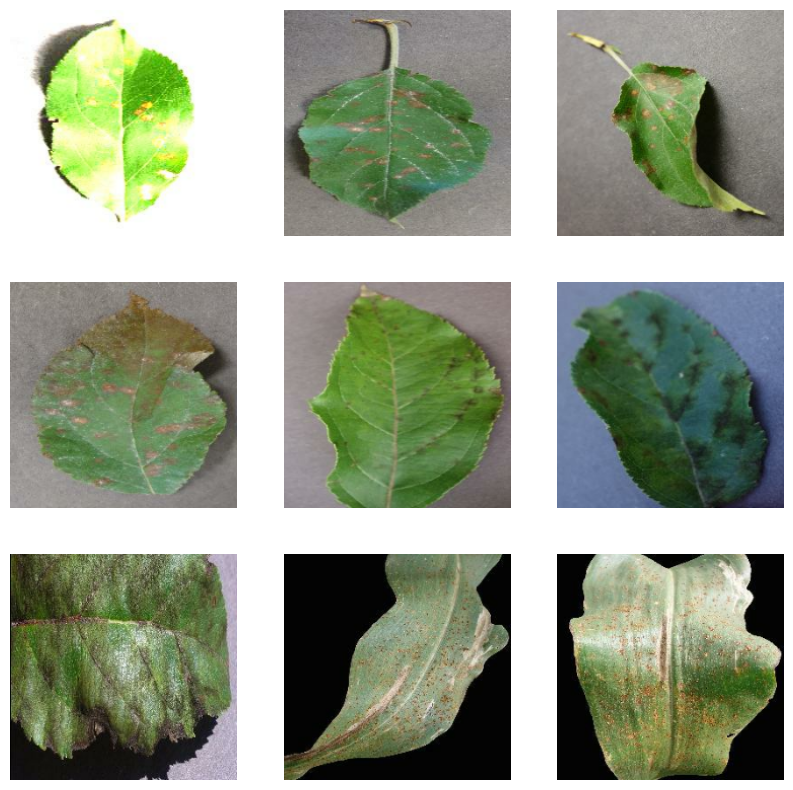

In [10]:
# Create a figure for our test plot
plt.figure(figsize=(10, 10))

# Take 1 batch from the test dataset. Notice there are no labels here.
for images in test_dataset.take(1):
    # Loop over the first 9 images
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        
        plt.imshow(images[i].numpy().astype("uint8"))
        
        # We don't have true labels for test, but we can print the filename if we want!
        # Here we just show the images without titles.
        plt.axis("off")


In [11]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, RandomFlip, RandomRotation, RandomZoom

# 1. Define the input shape based on the image size we used earlier
IMG_SHAPE = IMG_SIZE + (3,) # (224, 224, 3) because images have 3 color channels (RGB)

# 2. Get the pre-trained ImageNet configuration
# include_top=False means we don't want the final ImageNet classification layer (which has 1000 classes)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SHAPE,
    include_top=False,
    weights='imagenet'
)

# 3. Freeze the base model so its pre-trained weights aren't updated during the first training phase
base_model.trainable = False

# 4. Build the custom model on top
# We use the global `class_names` variable we saved earlier!
num_classes = len(class_names) 

# Create a data augmentation stage to prevent overfitting
data_augmentation = Sequential([
    RandomFlip("horizontal_and_vertical"),
    RandomRotation(0.2),
    RandomZoom(0.2),
])

# We use a Sequential model to stack our custom layers on top of the base model
model = Sequential([
    data_augmentation, # Apply data augmentation
    base_model,
    
    # Convert the 2D feature maps to 1D feature vectors
    GlobalAveragePooling2D(),
    
    # Add a Dropout layer to help prevent overfitting
    Dropout(0.5), # Increased from 0.2 to 0.5 for stronger regularization
    
    # This is the final classification layer with a 'softmax' activation
    # It will output the probabilities for the different plant classes
    Dense(num_classes, activation='softmax')
])

# 5. Compile the model
# We use sparse_categorical_crossentropy because our labels are integers, not one-hot encoded
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

# 6. Look at the architecture
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ ?                           │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [16]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Stop training early if validation loss stops improving
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Save the best model during training
model_checkpoint = ModelCheckpoint(
    'best_plant_model.keras',
    monitor='val_accuracy',
    save_best_only=True
)

callbacks = [early_stopping, model_checkpoint]


In [13]:

history = model.fit(
    train_dataset,
    epochs=5,  
    callbacks=callbacks,
    validation_data=val_dataset,
)


Epoch 1/5


195/195 ━━━━━━━━━━━━━━━━━━━━ 198s 901ms/step - accuracy: 0.6091 - loss: 0.9381 - val_accuracy: 0.6004 - val_loss: 0.9425
Epoch 2/5
195/195 ━━━━━━━━━━━━━━━━━━━━ 96s 494ms/step - accuracy: 0.7557 - loss: 0.5925 - val_accuracy: 0.6100 - val_loss: 0.9315
Epoch 3/5
195/195 ━━━━━━━━━━━━━━━━━━━━ 90s 460ms/step - accuracy: 0.7782 - loss: 0.5401 - val_accuracy: 0.6332 - val_loss: 0.8402
Epoch 4/5
195/195 ━━━━━━━━━━━━━━━━━━━━ 90s 460ms/step - accuracy: 0.7986 - loss: 0.5090 - val_accuracy: 0.6364 - val_loss: 0.8848
Epoch 5/5
195/195 ━━━━━━━━━━━━━━━━━━━━ 88s 451ms/step - accuracy: 0.8009 - loss: 0.4971 - val_accuracy: 0.6512 - val_loss: 0.8566


In [14]:

print("Evaluating model performance...")
loss, accuracy = model.evaluate(train_dataset) 

print(f"Final Model Loss: {loss:.4f}")
print(f"Final Model Accuracy: {accuracy * 100:.2f}%")


Evaluating model performance...
195/195 ━━━━━━━━━━━━━━━━━━━━ 55s 282ms/step - accuracy: 0.6349 - loss: 0.8886
Final Model Loss: 0.8886
Final Model Accuracy: 63.49%


In [15]:
import os

# Define the path where you want to save the final model
save_path = "final_plant_disease_model.keras"

# Save the entire model to a file
model.save(save_path)
print(f"Model successfully saved to: {save_path}")

# Optional: List the files in the directory to confirm it's there
print("Files in current directory:")
for f in os.listdir('.'):
    if f.endswith('.keras'):
        print("-", f)


Model successfully saved to: final_plant_disease_model.keras
Files in current directory:
- best_plant_model.keras
- final_plant_disease_model.keras
